# Multi-Star Dispersion Demo

This notebook demonstrates how to disperse multiple stars through the Roman grism
using wavelength-dependent PSFs and realistic stellar spectra.

**Key features demonstrated:**
1. **Realistic stellar spectra** using synphot/stsynphot for flux calibration
2. **Magnitude-based catalog** sampling from galacticus simulation
3. **Fine wavelength sampling** (2Å spacing for accurate spectral features)
4. **Sensitivity curves** for each spectral order
5. **Parallel dispersion** using JAX fori_loop for efficient GPU execution

**Memory-efficient implementation:** The star disperser uses wavelength chunking
internally (default 1000/chunk), keeping peak memory at ~620 MB regardless of
total wavelength count.

In [1]:
# Imports
import os
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm
from astropy.io import fits
import astropy.units as u
import jax
import jax.numpy as jnp

# Synphot for stellar spectra
import synphot as syn
import stsynphot as stsyn

# Roman disperser
from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj
import roman_disperser.star_disperser as star_disperser
import roman_disperser.psf_model as psf_model

# Use larger fonts for better readability
plt.rcParams['font.size'] = 11

## Configuration

All key parameters are configurable here.

In [2]:
# ============================================================================
# CONFIGURATION - Modify these parameters as needed
# ============================================================================

# Number of stars to disperse
N_STARS = 100

# Magnitude range (F158 AB mag)
MAG_MIN = 15.0
MAG_MAX = 22.0

# Field boundaries in SCA coordinates (FITS 1-indexed)
# Using a margin to keep stars away from detector edges
X_MIN = 100.0
X_MAX = 3988.0
Y_MIN = 100.0
Y_MAX = 3988.0

# Wavelength configuration
LAM_MIN = 0.9    # Minimum wavelength (microns) - PSF cache valid region
LAM_MAX = 2.0    # Maximum wavelength (microns)
DLAM_ANGSTROMS = 2.0  # Wavelength spacing in Angstroms (2Å gives ~5500 wavelengths)

# Spectral orders to disperse
ORDERS = ['0', '1', '2']

# Detector and SCA
DETECTOR = 'WFI05'  # Central detector
SCA = 5

# PSF cache directory
PSF_CACHE_DIR = 'data/psf_cache'

# Random seed for reproducibility
RANDOM_SEED = 42

# Compute derived quantities
dlam_um = DLAM_ANGSTROMS / 1e4  # Convert Å to μm
n_wavelength = int((LAM_MAX - LAM_MIN) / dlam_um) + 1

print(f"Configuration:")
print(f"  N_STARS: {N_STARS}")
print(f"  Magnitude range: {MAG_MIN} - {MAG_MAX} AB mag")
print(f"  Field: X=[{X_MIN}, {X_MAX}], Y=[{Y_MIN}, {Y_MAX}]")
print(f"  Wavelength: {LAM_MIN}-{LAM_MAX} μm, spacing={DLAM_ANGSTROMS}Å")
print(f"  Number of wavelength samples: {n_wavelength}")
print(f"  Orders: {ORDERS}")
print(f"  Detector: {DETECTOR} (SCA {SCA})")

Configuration:
  N_STARS: 100
  Magnitude range: 15.0 - 22.0 AB mag
  Field: X=[100.0, 3988.0], Y=[100.0, 3988.0]
  Wavelength: 0.9-2.0 μm, spacing=2.0Å
  Number of wavelength samples: 5501
  Orders: ['0', '1', '2']
  Detector: WFI05 (SCA 5)


---
# Part 1: Data Preparation

## 1.1 Load Stellar Spectrum Template

We use a G0V stellar template from the Bruzual atlas via synphot.

In [3]:
# Load G0V stellar template from Bruzual atlas
pysyn_cdbs = os.environ.get('PYSYN_CDBS', '')
if not pysyn_cdbs:
    print("WARNING: PYSYN_CDBS environment variable not set.")
    print("         Synphot reference data may not be available.")
    print("         Set PYSYN_CDBS to point to your synphot reference data directory.")

# Load G0V template (bz_24.fits corresponds to G0V in the Bruzual atlas)
template_path = os.path.join(pysyn_cdbs, 'grid', 'bz77', 'bz_24.fits')
star_spec = syn.SourceSpectrum.from_file(template_path)

print(f"Loaded stellar template: {template_path}")
print(f"  Spectral type: G0V (Bruzual atlas)")

Loaded stellar template: /Users/npadmana/data/synphot/grp/redcat/trds/grid/bz77/bz_24.fits
  Spectral type: G0V (Bruzual atlas)


In [4]:
# Load the Roman WFI F158 bandpass for flux normalization
wfi_f158 = stsyn.band('roman, wfi, f158')
print(f"Loaded F158 bandpass for flux normalization")
print(f"  Pivot wavelength: {wfi_f158.pivot():.2f}")

Loaded F158 bandpass for flux normalization
  Pivot wavelength: 15748.67 Angstrom


## 1.2 Create Wavelength Grid

In [5]:
# Create wavelength grid (in microns)
wavelengths = np.linspace(LAM_MIN, LAM_MAX, n_wavelength, dtype=np.float32)
wavelengths_jax = jnp.array(wavelengths)

# Also create in Angstroms for synphot
wavelengths_angstrom = wavelengths * 1e4

print(f"Wavelength grid:")
print(f"  Range: {wavelengths[0]:.4f} - {wavelengths[-1]:.4f} μm")
print(f"  Spacing: {(wavelengths[1] - wavelengths[0]) * 1e4:.2f} Å")
print(f"  N samples: {len(wavelengths)}")

Wavelength grid:
  Range: 0.9000 - 2.0000 μm
  Spacing: 2.00 Å
  N samples: 5501


## 1.3 Generate Star Catalog

Sample magnitudes from the galacticus simulation catalog and generate random positions.

In [6]:
# Load star catalog from galacticus simulation
project_root = Path(os.environ.get("PIXI_PROJECT_ROOT", "."))
catalog_path = project_root / "data" / "stars" / "sim_star_cat_galacticus.txt"

# Read catalog (columns: index, star_template_index, magnitude, RA, DEC)
catalog_data = np.loadtxt(catalog_path, skiprows=1)
catalog_magnitudes = catalog_data[:, 2]  # Third column is magnitude

print(f"Loaded catalog: {catalog_path.name}")
print(f"  Total stars: {len(catalog_magnitudes)}")
print(f"  Magnitude range: {catalog_magnitudes.min():.1f} - {catalog_magnitudes.max():.1f}")

Loaded catalog: sim_star_cat_galacticus.txt
  Total stars: 87039
  Magnitude range: 12.0 - 25.0


In [7]:
# Filter catalog to desired magnitude range
mag_mask = (catalog_magnitudes >= MAG_MIN) & (catalog_magnitudes <= MAG_MAX)
valid_magnitudes = catalog_magnitudes[mag_mask]

print(f"Stars in magnitude range [{MAG_MIN}, {MAG_MAX}]: {len(valid_magnitudes)}")

# Random number generator
rng = np.random.default_rng(RANDOM_SEED)

# Sample magnitudes (with replacement if needed)
if len(valid_magnitudes) >= N_STARS:
    magnitudes = rng.choice(valid_magnitudes, size=N_STARS, replace=False)
else:
    print(f"  Note: Sampling with replacement (only {len(valid_magnitudes)} available)")
    magnitudes = rng.choice(valid_magnitudes, size=N_STARS, replace=True)

# Generate random positions
x_positions = rng.uniform(X_MIN, X_MAX, size=N_STARS).astype(np.float32)
y_positions = rng.uniform(Y_MIN, Y_MAX, size=N_STARS).astype(np.float32)

print(f"\nGenerated {N_STARS} stars:")
print(f"  Magnitude: {magnitudes.min():.1f} - {magnitudes.max():.1f} (median: {np.median(magnitudes):.1f})")
print(f"  X range: {x_positions.min():.0f} - {x_positions.max():.0f}")
print(f"  Y range: {y_positions.min():.0f} - {y_positions.max():.0f}")

Stars in magnitude range [15.0, 22.0]: 33669

Generated 100 stars:
  Magnitude: 15.5 - 22.0 (median: 20.5)
  X range: 184 - 3958
  Y range: 154 - 3909


## 1.4 Helper Function for Spectrum Generation

Create a helper function that properly normalizes spectra via synphot.

In [8]:
def get_normalized_spectrum(star_spec, magnitude, wavelengths_angstrom, band=wfi_f158):
    """
    Normalize a stellar spectrum to a given F158 magnitude.

    Parameters
    ----------
    star_spec : synphot.SourceSpectrum
        Stellar template (e.g., G0V from Bruzual atlas)
    magnitude : float
        Target F158 AB magnitude
    wavelengths_angstrom : array
        Wavelength grid in Angstroms
    band : synphot.SpectralElement
        Bandpass for normalization (default: F158)

    Returns
    -------
    flam : array
        Flux in erg/s/cm^2/Å at each wavelength
    """
    norm_spec = star_spec.normalize(magnitude * u.ABmag, band=band)
    return norm_spec(wavelengths_angstrom * u.AA, flux_unit=syn.units.FLAM).value

## 1.5 Create Spectra Array

Generate normalized spectra for all stars.

In [9]:
print(f"Generating normalized spectra for {N_STARS} stars...")
t0 = time.time()

# Pre-allocate array
spectra_flam = np.zeros((N_STARS, len(wavelengths)), dtype=np.float32)

# Generate spectrum for each magnitude
# Note: This uses synphot's normalize() for proper flux calibration
for i, mag in enumerate(magnitudes):
    spectra_flam[i] = get_normalized_spectrum(star_spec, mag, wavelengths_angstrom)
    if (i + 1) % 20 == 0:
        print(f"  {i + 1}/{N_STARS} stars processed...")

elapsed = time.time() - t0
print(f"\nSpectrum generation complete in {elapsed:.2f} seconds")

# Convert to JAX array
spectra_flam_jax = jnp.array(spectra_flam)

# Show some statistics
print(f"\nSpectra array shape: {spectra_flam.shape}")
print(f"  Memory: {spectra_flam.nbytes / 1e6:.1f} MB")
print(f"  Peak flux (brightest star): {spectra_flam.max():.3e} erg/s/cm^2/Å")
print(f"  Min flux (faintest star): {spectra_flam[spectra_flam > 0].min():.3e} erg/s/cm^2/Å")

Generating normalized spectra for 100 stars...
  20/100 stars processed...
  40/100 stars processed...
  60/100 stars processed...
  80/100 stars processed...
  100/100 stars processed...

Spectrum generation complete in 0.46 seconds

Spectra array shape: (100, 5501)
  Memory: 2.2 MB
  Peak flux (brightest star): 1.057e-15 erg/s/cm^2/Å
  Min flux (faintest star): 3.119e-19 erg/s/cm^2/Å


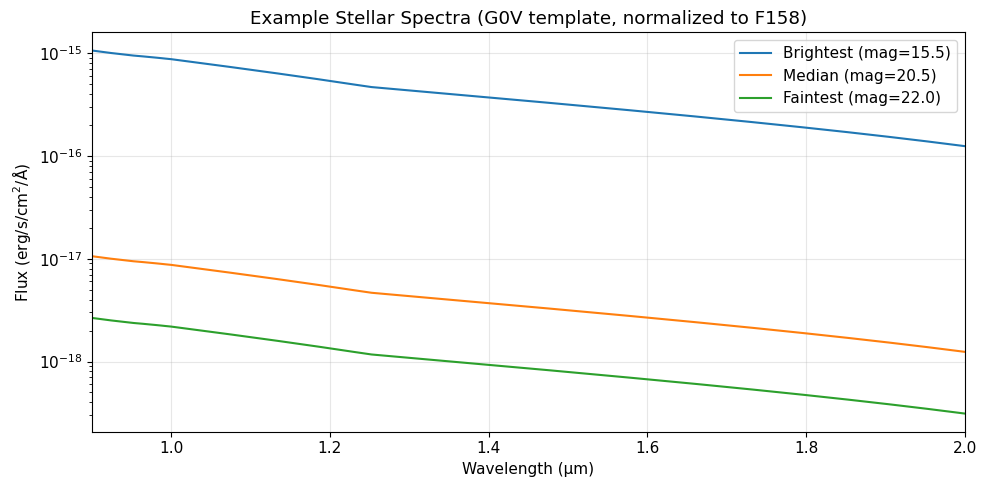

In [10]:
# Visualize a few spectra
fig, ax = plt.subplots(figsize=(10, 5))

# Plot a few example spectra (brightest, median, faintest)
sort_idx = np.argsort(magnitudes)
examples = [
    (sort_idx[0], 'Brightest'),
    (sort_idx[len(sort_idx)//2], 'Median'),
    (sort_idx[-1], 'Faintest'),
]

for idx, label in examples:
    ax.semilogy(wavelengths, spectra_flam[idx], 
                label=f"{label} (mag={magnitudes[idx]:.1f})", lw=1.5)

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Flux (erg/s/cm$^2$/Å)')
ax.set_title('Example Stellar Spectra (G0V template, normalized to F158)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0.9, 2.0)
plt.tight_layout()
plt.show()

---
# Part 2: Load Sensitivities

Load the grism sensitivity curves for each spectral order and interpolate to our wavelength grid.

In [11]:
# Define sensitivity file paths
sensitivity_files = {
    '1': project_root / 'data' / 'sensitivities' / 'SCA1_sens_12052024.fits',
    '0': project_root / 'data' / 'sensitivities' / 'SCA1_sens_12052024_order0.fits',
    '2': project_root / 'data' / 'sensitivities' / 'SCA1_sens_12052024_order2.fits',
}

# Load and interpolate sensitivities
sensitivities = {}
print("Loading sensitivity curves...")

for order, fpath in sensitivity_files.items():
    with fits.open(fpath) as hdul:
        sens_data = hdul[1].data
        wl_sens = sens_data['WAVELENGTH'] / 1e4  # Å to μm
        sens_vals = sens_data['SENSITIVITY']
        
        # Interpolate to our wavelength grid
        sens_interp = np.interp(wavelengths, wl_sens, sens_vals)
        sensitivities[order] = jnp.array(sens_interp.astype(np.float32))
        
        # Find peak in our range
        peak_idx = np.argmax(sens_interp)
        print(f"  Order {order}: peak = {sens_interp.max():.3e} at λ = {wavelengths[peak_idx]:.3f} μm")

Loading sensitivity curves...
  Order 1: peak = 1.415e+16 at λ = 1.482 μm
  Order 0: peak = 4.283e+14 at λ = 1.901 μm
  Order 2: peak = 2.104e+14 at λ = 1.003 μm


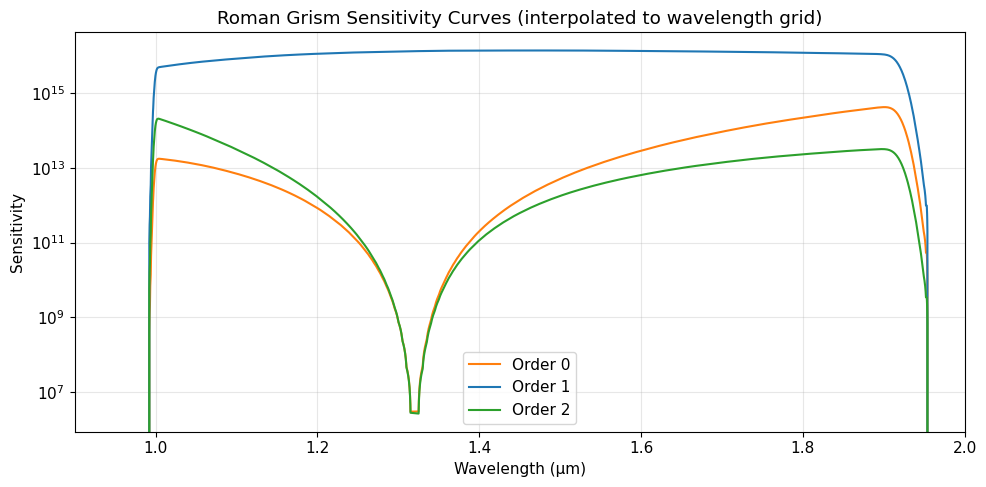

In [12]:
# Plot sensitivity curves
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'0': 'C1', '1': 'C0', '2': 'C2'}
for order in ORDERS:
    ax.semilogy(wavelengths, sensitivities[order], 
                label=f'Order {order}', color=colors[order], lw=1.5)

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Sensitivity')
ax.set_title('Roman Grism Sensitivity Curves (interpolated to wavelength grid)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0.9, 2.0)
plt.tight_layout()
plt.show()

---
# Part 3: Load Model and Create Dispersers

Load the optical model, PSF payloads, and create JIT-compiled star dispersers.

In [13]:
# Load optical model
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"
model = RomanOpticalModel(config_file=str(config_path))
print(f"Loaded optical model: {config_path.name}")

Loaded optical model: Roman_grism_OpticalModel_v0.8.yaml


In [14]:
# Create optical model payloads for all orders
optical_payloads = {}
for order in ORDERS:
    optical_payloads[order] = omj.make_sca_payload(model, sca=SCA, order=order)
    print(f"Created optical payload for SCA {SCA}, order {order}")

Created optical payload for SCA 5, order 0
Created optical payload for SCA 5, order 1
Created optical payload for SCA 5, order 2


In [15]:
# Load PSF payloads
cache_dir = project_root / PSF_CACHE_DIR

psf_payloads = {}
psf_orders_to_load = ['0', '1']  # Order 2 reuses order 1 PSFs

print("Loading PSF payloads...")
t0 = time.time()

for order in psf_orders_to_load:
    try:
        psf_payloads[order] = psf_model.get_or_make_psf_payload(
            detector=DETECTOR,
            order=order,
            cache_dir=str(cache_dir),
            verbose=True,
        )
        print(f"  Order {order}: Grid shape {psf_payloads[order]['psf_grid'].shape}")
    except FileNotFoundError:
        print(f"\nNo cached PSF found for order {order}")
        print("To generate PSF cache, run:")
        print(f"  pixi run python scripts/generate_psf_caches.py --detectors {DETECTOR} --orders {order}")
        raise

# Order 2 uses Order 1 PSFs (same grism optical path)
psf_payloads['2'] = psf_payloads['1']
print(f"  Order 2: Using Order 1 PSFs")

print(f"\nPSF payloads loaded in {time.time() - t0:.2f} seconds")

Loading PSF payloads...
Loading PSF payload from cache: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz
Loaded PSF cache: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI05, Order: 0
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
  Order 0: Grid shape (4, 4, 56, 184, 184)
Loading PSF payload from cache: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
Loaded PSF cache: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI05, Order: 1
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
  Order 1: Grid shape (4, 4, 56, 184, 184)
  Order 2: Using Order 1 PSFs

PSF payloads loaded in 1.69 seconds


In [16]:
# Create JIT-compiled star dispersers for each order
print("Creating star dispersers...")
star_dispersers = {}

for order in ORDERS:
    star_dispersers[order] = star_disperser.make_star_disperser(
        psf_payloads[order],
        optical_payloads[order]
    )
    print(f"  Order {order}: disperser created")

print("\nNote: First call to each disperser will trigger JIT compilation.")

Creating star dispersers...
  Order 0: disperser created
  Order 1: disperser created
  Order 2: disperser created

Note: First call to each disperser will trigger JIT compilation.


---
# Part 4: Parallel Dispersion

Disperse all stars through all orders using JAX's `fori_loop` for efficient sequential accumulation.

In [17]:
# Convert positions to JAX arrays
x_positions_jax = jnp.array(x_positions)
y_positions_jax = jnp.array(y_positions)

# Compute wavelength spacing in Angstroms for flux conversion
dlam_angstroms = (wavelengths[1] - wavelengths[0]) * 1e4  # μm to Å

print(f"Wavelength spacing: {dlam_angstroms:.2f} Å")

Wavelength spacing: 2.00 Å


In [18]:
# JIT warmup - trigger compilation before timed run
# This ensures the dispersion timing reflects pure execution, not compilation overhead.
# We must use the same array shapes as the actual computation, since JAX recompiles
# when shapes change.
print("JIT warmup (compiling dispersers)...")

warmup_output = jnp.zeros((4088, 4088), dtype=jnp.float32)

# Use actual wavelength array and a real spectrum to match shapes
warmup_flux = spectra_flam_jax[0] * sensitivities['1'] * dlam_angstroms

t0 = time.time()
for order in ORDERS:
    t_order = time.time()
    # Disperse a dummy star at detector center
    _ = star_dispersers[order](2000.0, 2000.0, wavelengths_jax, warmup_flux, warmup_output)
    _.block_until_ready()
    print(f"  Order {order}: compiled in {time.time() - t_order:.2f}s")

print(f"Total warmup time: {time.time() - t0:.2f}s")

JIT warmup (compiling dispersers)...
  Order 0: compiled in 1.85s
  Order 1: compiled in 1.83s
  Order 2: compiled in 1.73s
Total warmup time: 5.41s


In [19]:
def disperse_all_stars_order(order, x_positions, y_positions, spectra_flam, output):
    """
    Disperse all stars for one spectral order using fori_loop.
    
    Parameters
    ----------
    order : str
        Spectral order ('0', '1', or '2')
    x_positions, y_positions : jnp.ndarray
        [N_STARS] SCA coordinates of stars
    spectra_flam : jnp.ndarray
        [N_STARS, N_wl] spectra in FLAM units
    output : jnp.ndarray
        [4088, 4088] detector accumulator
    
    Returns
    -------
    output : jnp.ndarray
        Updated detector array
    """
    sens = sensitivities[order]
    disperser = star_dispersers[order]
    
    def body_fn(i, output):
        # Convert FLAM to counts: FLAM * sensitivity * dlam (Å)
        # sensitivity has units such that FLAM * sens * dlam = counts
        counts = spectra_flam[i] * sens * dlam_angstroms
        return disperser(x_positions[i], y_positions[i], wavelengths_jax, counts, output)
    
    return jax.lax.fori_loop(0, len(x_positions), body_fn, output)

In [20]:
# Disperse all stars through all orders
print(f"Dispersing {N_STARS} stars through {len(ORDERS)} orders...")
print(f"  Wavelength samples: {len(wavelengths)}")
print(f"  Total operations: {N_STARS * len(ORDERS)} star×order combinations")
print()

# Initialize output detector
output = jnp.zeros((4088, 4088), dtype=jnp.float32)

# Track timing per order
order_times = {}

t0_total = time.time()

for order in ORDERS:
    print(f"Order {order}:")
    t0_order = time.time()
    
    output = disperse_all_stars_order(
        order, x_positions_jax, y_positions_jax, spectra_flam_jax, output
    )
    output.block_until_ready()  # Wait for computation to complete
    
    elapsed_order = time.time() - t0_order
    order_times[order] = elapsed_order
    print(f"  Completed in {elapsed_order:.2f} seconds ({elapsed_order/N_STARS:.3f}s per star)")

total_time = time.time() - t0_total
print(f"\nTotal dispersion time: {total_time:.2f} seconds")
print(f"  Per star (all orders): {total_time/N_STARS:.3f} seconds")
print(f"  Throughput: {N_STARS * len(ORDERS) / total_time:.1f} star×order/second")

Dispersing 100 stars through 3 orders...
  Wavelength samples: 5501
  Total operations: 300 star×order combinations

Order 0:
  Completed in 47.93 seconds (0.479s per star)
Order 1:
  Completed in 61.31 seconds (0.613s per star)
Order 2:
  Completed in 53.45 seconds (0.534s per star)

Total dispersion time: 162.69 seconds
  Per star (all orders): 1.627 seconds
  Throughput: 1.8 star×order/second


In [21]:
# Basic statistics on output
print(f"\nOutput statistics:")
print(f"  Total flux: {float(output.sum()):.6e}")
print(f"  Peak flux: {float(output.max()):.6e}")
print(f"  Non-zero pixels: {int((output > 0).sum())} ({100 * (output > 0).sum() / output.size:.2f}%)")


Output statistics:
  Total flux: 2.478324e+05
  Peak flux: 3.731344e+01
  Non-zero pixels: 7808056 (46.72%)


---
# Part 5: Visualization

Visualize the dispersed star field.

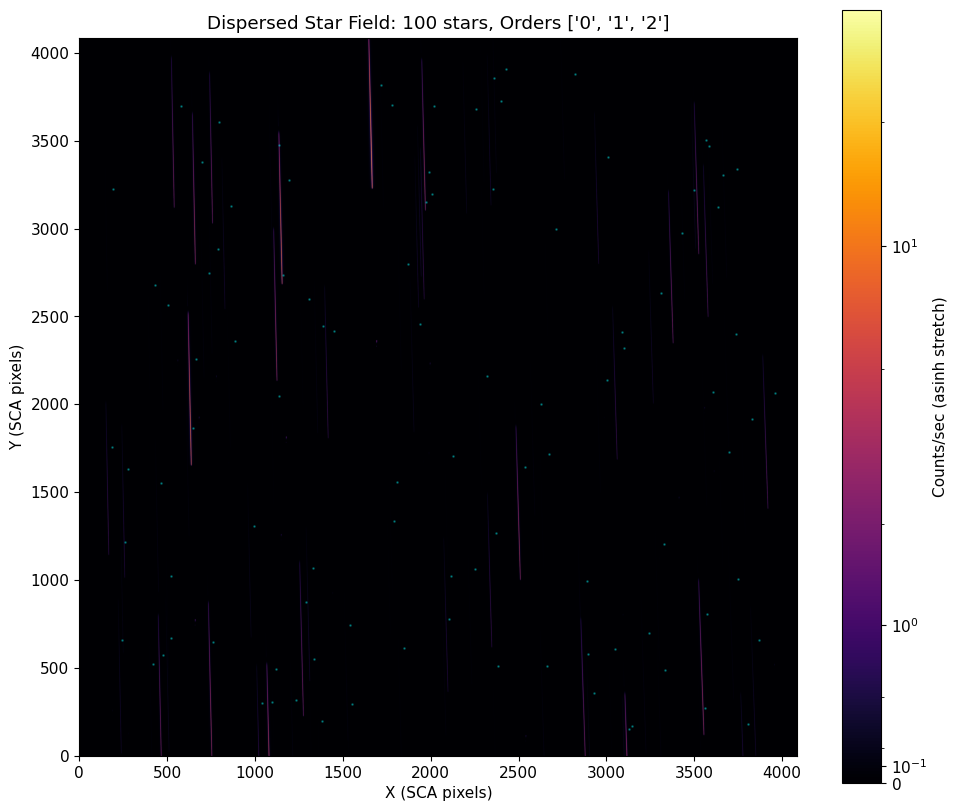

In [22]:
# Full detector view with asinh scaling
#
# Asinh scaling is the standard for astronomical imaging (used by SDSS).
# It behaves linearly near zero and logarithmically for large values.
# The linear_width parameter sets the transition point - we use ~1 count/sec,
# which is near the typical zodiacal light background for Roman grism observations.
# This keeps background noise in the linear regime while compressing bright sources.

fig, ax = plt.subplots(figsize=(10, 10))

output_np = np.array(output)
linear_width = 1.0  # counts/sec, near typical zodiacal background

norm = AsinhNorm(linear_width=linear_width, vmin=0, vmax=output_np.max())
im = ax.imshow(
    output_np,
    origin='lower',
    cmap='inferno',
    norm=norm,
)
ax.scatter(x_positions, y_positions, s=3, c='cyan', alpha=0.3, marker='.')
ax.set_title(f'Dispersed Star Field: {N_STARS} stars, Orders {ORDERS}')
ax.set_xlabel('X (SCA pixels)')
ax.set_ylabel('Y (SCA pixels)')
plt.colorbar(im, ax=ax, label='Counts/sec (asinh stretch)', shrink=0.8)

plt.tight_layout()
plt.show()

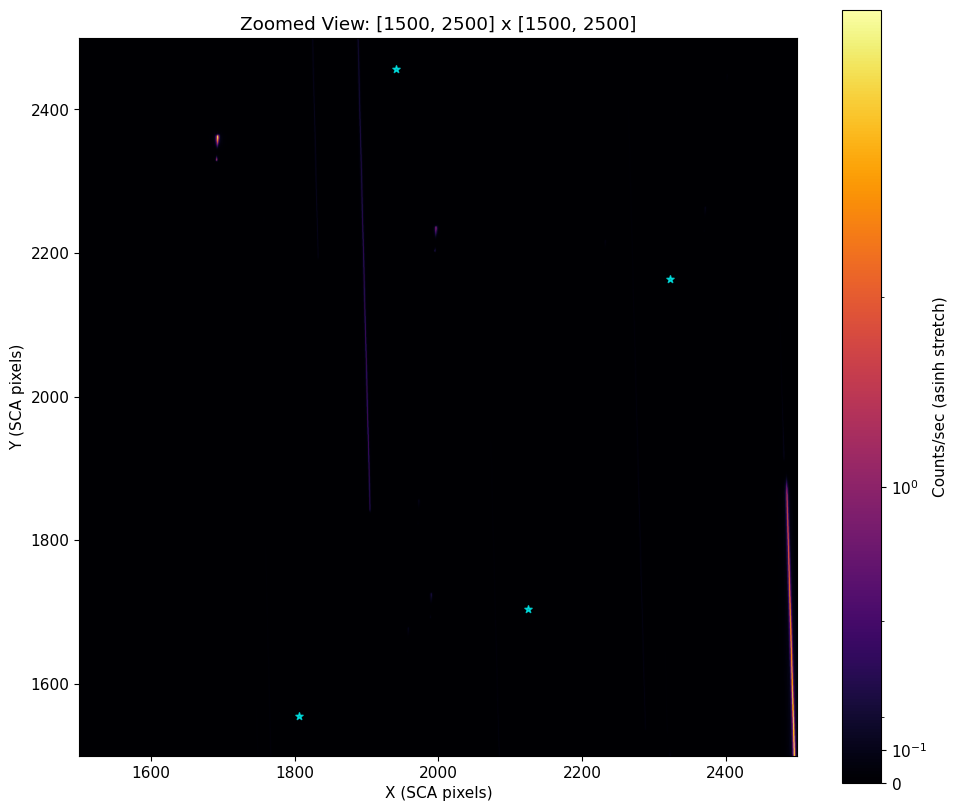

In [23]:
# Zoomed view with asinh scaling
center_x, center_y = 2000, 2000
zoom_size = 500

x_lo = max(0, center_x - zoom_size)
x_hi = min(4088, center_x + zoom_size)
y_lo = max(0, center_y - zoom_size)
y_hi = min(4088, center_y + zoom_size)

zoomed = output_np[y_lo:y_hi, x_lo:x_hi]

fig, ax = plt.subplots(figsize=(10, 10))

# Stars in this region
in_region = ((x_positions >= x_lo) & (x_positions <= x_hi) & 
             (y_positions >= y_lo) & (y_positions <= y_hi))

norm = AsinhNorm(linear_width=linear_width, vmin=0, vmax=zoomed.max())
im = ax.imshow(
    zoomed,
    origin='lower',
    cmap='inferno',
    extent=[x_lo, x_hi, y_lo, y_hi],
    norm=norm,
)
ax.scatter(x_positions[in_region], y_positions[in_region], 
           s=30, c='cyan', alpha=0.7, marker='*')
ax.set_title(f'Zoomed View: [{x_lo}, {x_hi}] x [{y_lo}, {y_hi}]')
ax.set_xlabel('X (SCA pixels)')
ax.set_ylabel('Y (SCA pixels)')
plt.colorbar(im, ax=ax, label='Counts/sec (asinh stretch)', shrink=0.8)

plt.tight_layout()
plt.show()

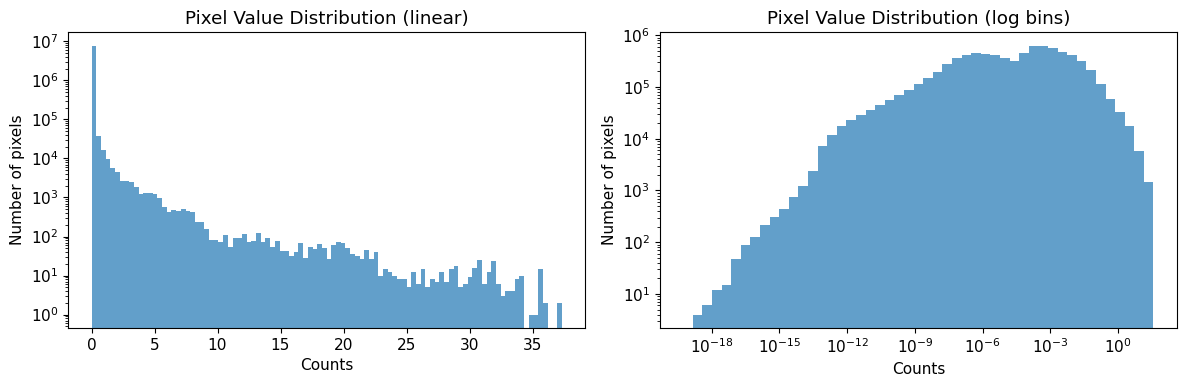

In [24]:
# Histogram of pixel values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear histogram
ax = axes[0]
nonzero = output[output > 0]
ax.hist(nonzero, bins=100, edgecolor='none', alpha=0.7)
ax.set_xlabel('Counts')
ax.set_ylabel('Number of pixels')
ax.set_title('Pixel Value Distribution (linear)')
ax.set_yscale('log')

# Log histogram
ax = axes[1]
log_bins = np.logspace(np.log10(nonzero.min()), np.log10(nonzero.max()), 50)
ax.hist(nonzero, bins=log_bins, edgecolor='none', alpha=0.7)
ax.set_xlabel('Counts')
ax.set_ylabel('Number of pixels')
ax.set_title('Pixel Value Distribution (log bins)')
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## Magnitude-Brightness Check

Verify that brighter stars (lower magnitude) produce brighter traces.

In [25]:
# Disperse a few stars individually to check brightness scaling
print("Checking magnitude-brightness relationship...")

# Select 3 stars with different magnitudes
test_indices = [np.argmin(magnitudes), len(magnitudes)//2, np.argmax(magnitudes)]
test_outputs = []

for i, idx in enumerate(test_indices):
    test_output = jnp.zeros((4088, 4088), dtype=jnp.float32)
    
    # Disperse through order 1 only for simplicity
    counts = spectra_flam_jax[idx] * sensitivities['1'] * dlam_angstroms
    test_output = star_dispersers['1'](
        x_positions_jax[idx], y_positions_jax[idx],
        wavelengths_jax, counts, test_output
    )
    
    total_flux = float(test_output.sum())
    mag = magnitudes[idx]
    test_outputs.append(test_output)
    print(f"  Star {idx}: mag={mag:.1f}, total flux={total_flux:.3e}")

# Check flux ratios vs magnitude differences
print("\nFlux ratios (expected ~2.512^Δmag):")
for i in range(len(test_indices) - 1):
    flux_ratio = float(test_outputs[i].sum()) / float(test_outputs[i+1].sum())
    mag_diff = magnitudes[test_indices[i+1]] - magnitudes[test_indices[i]]
    expected_ratio = 2.512 ** mag_diff
    print(f"  Stars {i} vs {i+1}: flux ratio={flux_ratio:.3f}, expected={expected_ratio:.3f}")

Checking magnitude-brightness relationship...
  Star 23: mag=15.5, total flux=3.883e+04
  Star 50: mag=19.5, total flux=9.763e+02
  Star 2: mag=22.0, total flux=9.763e+01

Flux ratios (expected ~2.512^Δmag):
  Stars 0 vs 1: flux ratio=39.772, expected=39.818
  Stars 1 vs 2: flux ratio=10.000, expected=10.001


---
# Summary

This notebook demonstrated:

1. **Realistic stellar spectra**: Using synphot/stsynphot for proper flux calibration
   - G0V template from Bruzual atlas
   - Normalized to F158 AB magnitude

2. **Catalog-based simulation**: 
   - Sampled magnitudes from galacticus simulation
   - Random positions within detector bounds

3. **Fine wavelength sampling**:
   - 2Å spacing (~5500 wavelengths)
   - Memory-efficient chunked processing

4. **Multi-order dispersion**:
   - Orders 0, 1, 2 with sensitivity curves
   - Proper FLAM → counts conversion

5. **Efficient parallel processing**:
   - JAX `fori_loop` for sequential accumulation
   - JIT compilation for GPU acceleration

**Key technical points:**
- Star disperser uses wavelength chunking (default 1000/chunk) for memory efficiency
- Peak memory ~620 MB regardless of wavelength count
- First call includes JIT compilation overhead; subsequent calls are faster
- Flux scales correctly with magnitude (2.512× per magnitude)